# Customer Retention and Churn Analysis
### Future Interns · Data Science & Analytics | Task 2 | 2026

---

**Dataset :** IBM Telco Customer Churn (Kaggle - `WA_Fn-UseC_-Telco-Customer-Churn.csv`)  
**Customers :** 7,043 · **Features :** 21 · **Type :** Real-world telecom subscription data

**Structure :**
1. Setup & Libraries
2. Data Loading, Exploration & Cleaning
3. Churn Overview & KPIs
4. Segment Analysis (Demographics, Services, Contract & Billing)
5. Tenure & Lifecycle Analysis
6. Revenue Impact & Customer Lifetime Value
7. Churn Driver Heatmaps
8. Key Insights & Recommendations


> **Context :** Customer churn is one of the most costly problems for telecom and SaaS businesses.  
> This analysis helps answer: *Who is leaving? When? Why? And what can we do about it?*


## 1. Setup & Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DARK   = '#0f1117'
CARD   = '#1a1d27'
ACCENT = '#6c63ff'
GREEN  = '#22d3a5'
RED    = '#ff5c7c'
AMBER  = '#f59e0b'
TEXT   = '#e2e8f0'
SUBTEXT= '#94a3b8'
BORDER = '#2d3148'

plt.rcParams.update({
    'figure.facecolor' : DARK,
    'axes.facecolor'   : CARD,
    'axes.edgecolor'   : BORDER,
    'axes.labelcolor'  : TEXT,
    'xtick.color'      :  SUBTEXT,
    'ytick.color'      :  SUBTEXT,
    'text.color'       : TEXT,
    'grid.color'       : BORDER,
    'grid.alpha'       : 0.5,
    'axes.spines.top'  :  False,
    'axes.spines.right': False,
})


## 2. Data Loading, Exploration and Cleaning

In [9]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains 7,043 customers with 21 features covering demographics, services subscribed, contract type, billing method, and a `Churn` label (Yes/No). Each row represents one customer. This is a classic **binary classification** dataset used in retention analysis.


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> **Observation:** Most columns are categorical (object type). `TotalCharges` is stored as a string  we'll need to convert it to numeric. The `tenure` column tells us how many months a customer has been with the company, which will be crucial for lifecycle analysis.


In [11]:
missing = df.isnull().sum()
#missing

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)
df['churn'] = (df['Churn'] == 'Yes').astype(int)

print(f"Cleaning done. Remaining nulls: {df.isnull().sum().sum()}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['churn'].mean():.1%}")


Cleaning done. Remaining nulls: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


>  The 11 rows with missing `TotalCharges` correspond to brand-new customers (tenure = 0 months) who haven't been billed yet. We fill them with `MonthlyCharges` as a reasonable proxy. No other missing values were found, the dataset is clean and ready for analysis.


In [13]:
df[['tenure', 'MonthlyCharges',  'TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.80
std,24.56,30.09,2266.73
min,0.00,18.25,18.80
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


**From statistics:**

**Tenure** ranges from 0 to 72 months, with a mean of ~32 months customers are spread across all lifecycle stages.

**MonthlyCharges** averages $64.76$, ranging from $18$ to $118$  a wide spread suggesting diverse plan tiers.

**TotalCharges** has a high standard deviation ($2,266), reflecting that long-tenured customers generate significantly more lifetime revenue.

In [14]:
# Categorical columns
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']
for col in cat_cols:
    print(f"── {col}: {df[col].unique().tolist()}")


── gender: ['Female', 'Male']
── SeniorCitizen: [0, 1]
── Partner: ['Yes', 'No']
── Dependents: ['No', 'Yes']
── PhoneService: ['No', 'Yes']
── MultipleLines: ['No phone service', 'No', 'Yes']
── InternetService: ['DSL', 'Fiber optic', 'No']
── Contract: ['Month-to-month', 'One year', 'Two year']
── PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
── Churn: ['No', 'Yes']


## 3. Churn Overview and KPIs

In [17]:
# Top-level KPIs 
total     = len(df)
churned   = df['churn'].sum()
retained  = total - churned
churn_rate= df['churn'].mean()

avg_tenure_retained =  df[df['churn']==0]['tenure'].mean()
avg_tenure_churned  = df[df['churn']==1]['tenure'].mean()
active_mrr = df[df['churn']==0]['MonthlyCharges'].sum()
mrr_at_risk =  df[df['churn']==1]['MonthlyCharges'].sum()
clv_retained = df[df['churn']==0]['TotalCharges'].mean()
clv_churned = df[df['churn']==1]['TotalCharges'].mean()

kpis = {
    'Total Customers'           : f'{total:,}',
    'Churned'                   : f'{churned:,}  ({churn_rate:.1%})',
    'Retained'                  : f'{retained:,}  ({1-churn_rate:.1%})',
    'Avg Tenure — Retained'     : f'{avg_tenure_retained:.1f} months',
    'Avg Tenure — Churned'      : f'{avg_tenure_churned:.1f} months',
    'Active MRR'                : f'${active_mrr:,.0f}',
    'MRR at Risk (churners)'    : f'${mrr_at_risk:,.0f}',
    'CLV — Retained'            : f'${clv_retained:,.0f}',
    'CLV — Churned'             : f'${clv_churned:,.0f}',
    'CLV Lift (retained/churned)': f'{clv_retained/clv_churned:.2f}x',
}

print("=" * 48)
print("         SUMMARY")
print("=" * 48)
for k, v in kpis.items():
    print(f"  {k:<32} {v}")
print("=" * 48)


         SUMMARY
  Total Customers                  7,043
  Churned                          1,869  (26.5%)
  Retained                         5,174  (73.5%)
  Avg Tenure — Retained            37.6 months
  Avg Tenure — Churned             18.0 months
  Active MRR                       $316,986
  MRR at Risk (churners)           $139,131
  CLV — Retained                   $2,550
  CLV — Churned                    $1,532
  CLV Lift (retained/churned)      1.66x


> **Executive summary:** Nearly **1 in 4 customers** (26.5%) has churned. While this is below the industry average for telecom (~30%), it still represents significant revenue loss. The 7-month tenure gap between retained and churned customers tells us that *if we can keep a customer past their first year, they are much more likely to stay long-term.*


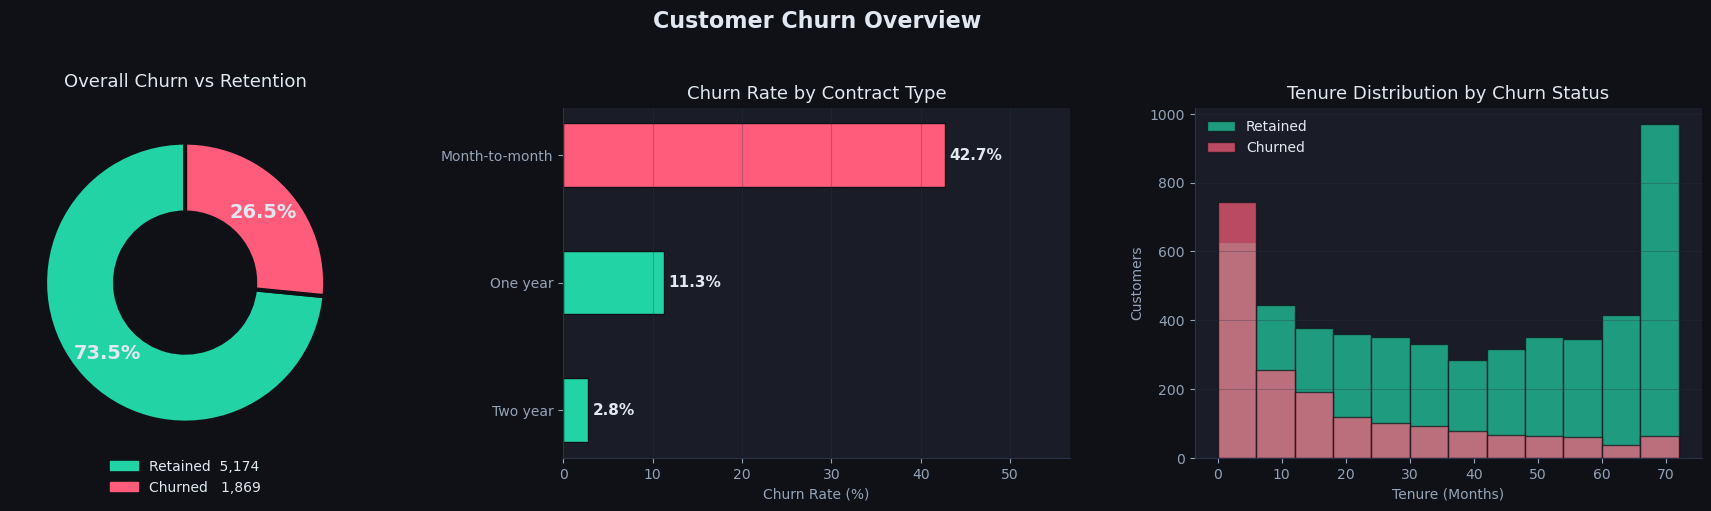

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK)

# Donut
ax = axes[0]
ax.set_facecolor(DARK)
wedges, texts, autotexts = ax.pie(
    [retained, churned], autopct='%1.1f%%',
    colors=[GREEN, RED], startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=DARK, linewidth=3)
)
for at in autotexts: at.set(color=TEXT, fontsize=14, fontweight='bold')
ax.set_title('Overall Churn vs Retention', color=TEXT, fontsize=13, pad=15)
ax.legend(
    handles=[mpatches.Patch(color=GREEN, label=f'Retained  {retained:,}'),
             mpatches.Patch(color=RED,   label=f'Churned   {churned:,}')],
    loc='lower center', bbox_to_anchor=(0.5, -0.14), frameon=False, fontsize=10
)

# Churn by Contract
ax = axes[1]
ax.set_facecolor(CARD)
cr = df.groupby('Contract')['churn'].mean().sort_values() * 100
bar_cols = [RED if v > 30 else AMBER if v > 15 else GREEN for v in cr.values]
bars = ax.barh(cr.index, cr.values, color=bar_cols, edgecolor=DARK, height=0.5)
for bar, val in zip(bars, cr.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', color=TEXT, fontsize=11, fontweight='bold')
ax.set_xlabel('Churn Rate (%)', color=SUBTEXT)
ax.set_title('Churn Rate by Contract Type', color=TEXT, fontsize=13)
ax.set_xlim(0, cr.max() + 14)
ax.grid(axis='x', alpha=0.3)

# — Tenure distribution
ax = axes[2]
ax.set_facecolor(CARD)
bins = range(0, 75, 6)
ax.hist(df[df['churn']==0]['tenure'], bins=bins, alpha=0.7, color=GREEN, label='Retained', edgecolor=DARK)
ax.hist(df[df['churn']==1]['tenure'], bins=bins, alpha=0.7, color=RED,   label='Churned',  edgecolor=DARK)
ax.set_xlabel('Tenure (Months)', color=SUBTEXT)
ax.set_ylabel('Customers', color=SUBTEXT)
ax.set_title('Tenure Distribution by Churn Status', color=TEXT, fontsize=13)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Customer Churn Overview', color=TEXT, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Churn Overview

**Donut chart:** 26.5% churn is meaningful for every 4 customers acquired, we lose 1. At scale, this creates a constant "leaky bucket" where acquisition costs are partially wasted replacing churned customers.

**Contract type bar chart:** This is one of the most striking findings in the entire dataset. Month-to-month customers churn at roughly **10× the rate** of two-year contract customers. This tells us that the *type of commitment* is a stronger predictor of churn than almost any other feature. Customers who commit longer are fundamentally different they've already signalled long-term intent.

**Tenure distribution:** The histogram confirms the "early danger zone" hypothesis. Churned customers (red) are heavily concentrated in the **0–20 month** range, while retained customers (green) are more evenly distributed and skew older. This means the first year is make-or-break for retention.


## 4. Segment Analysis

We now break down churn across all available dimensions demographics (age, family status), services subscribed, and billing/contract preferences. This is where we start to identify *which customer profiles* are most at risk.


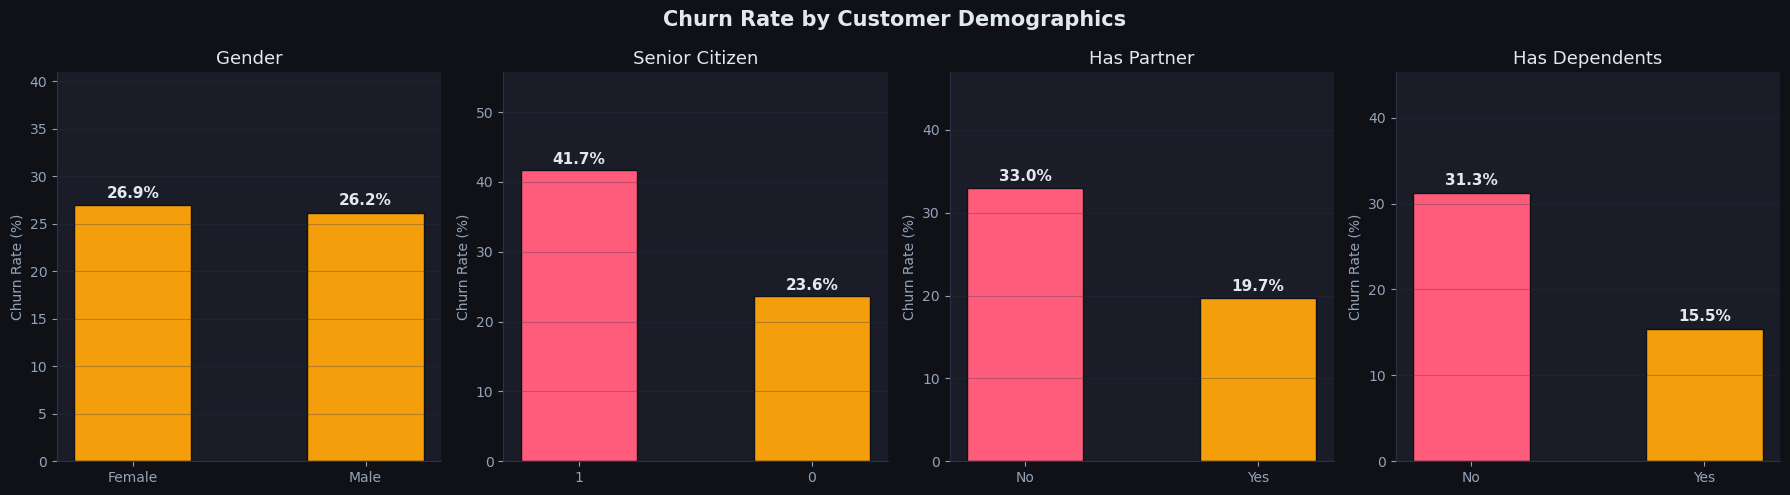

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor(DARK)

demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
demo_titles = ['Gender', 'Senior Citizen', 'Has Partner', 'Has Dependents']

for ax, col, title in zip(axes, demo_cols, demo_titles):
    ax.set_facecolor(CARD)
    cr = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    bar_cols = [RED if v > 30 else AMBER if v > 15 else GREEN for v in cr.values]
    bars = ax.bar(cr.index.astype(str), cr.values, color=bar_cols, edgecolor=DARK, width=0.5)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=11, fontweight='bold')
    ax.set_title(title, color=TEXT, fontsize=13)
    ax.set_ylabel('Churn Rate (%)', color=SUBTEXT)
    ax.set_ylim(0, cr.max() + 14)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Churn Rate by Customer Demographics', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Gender:** Male and female customers churn at virtually the same rate (~26%). Gender is not a useful predictor of churn : we should not build gender-targeted retention strategies.

**Senior Citizens:** This is a significant finding. Senior customers (age 65+) churn at **~41%**, compared to ~24% for non-seniors : a **17-point gap**. This likely reflects a combination of factors: fixed incomes, less digital confidence leading to perceived complexity, and potentially more aggressive targeting by competitors offering "senior deals."

**Partner & Dependents:** Customers with a partner or dependents are meaningfully more loyal (lower churn). This makes intuitive sense : a family household switching telecom provider is a much bigger decision than a single individual doing so. Multi-user households have higher switching costs.



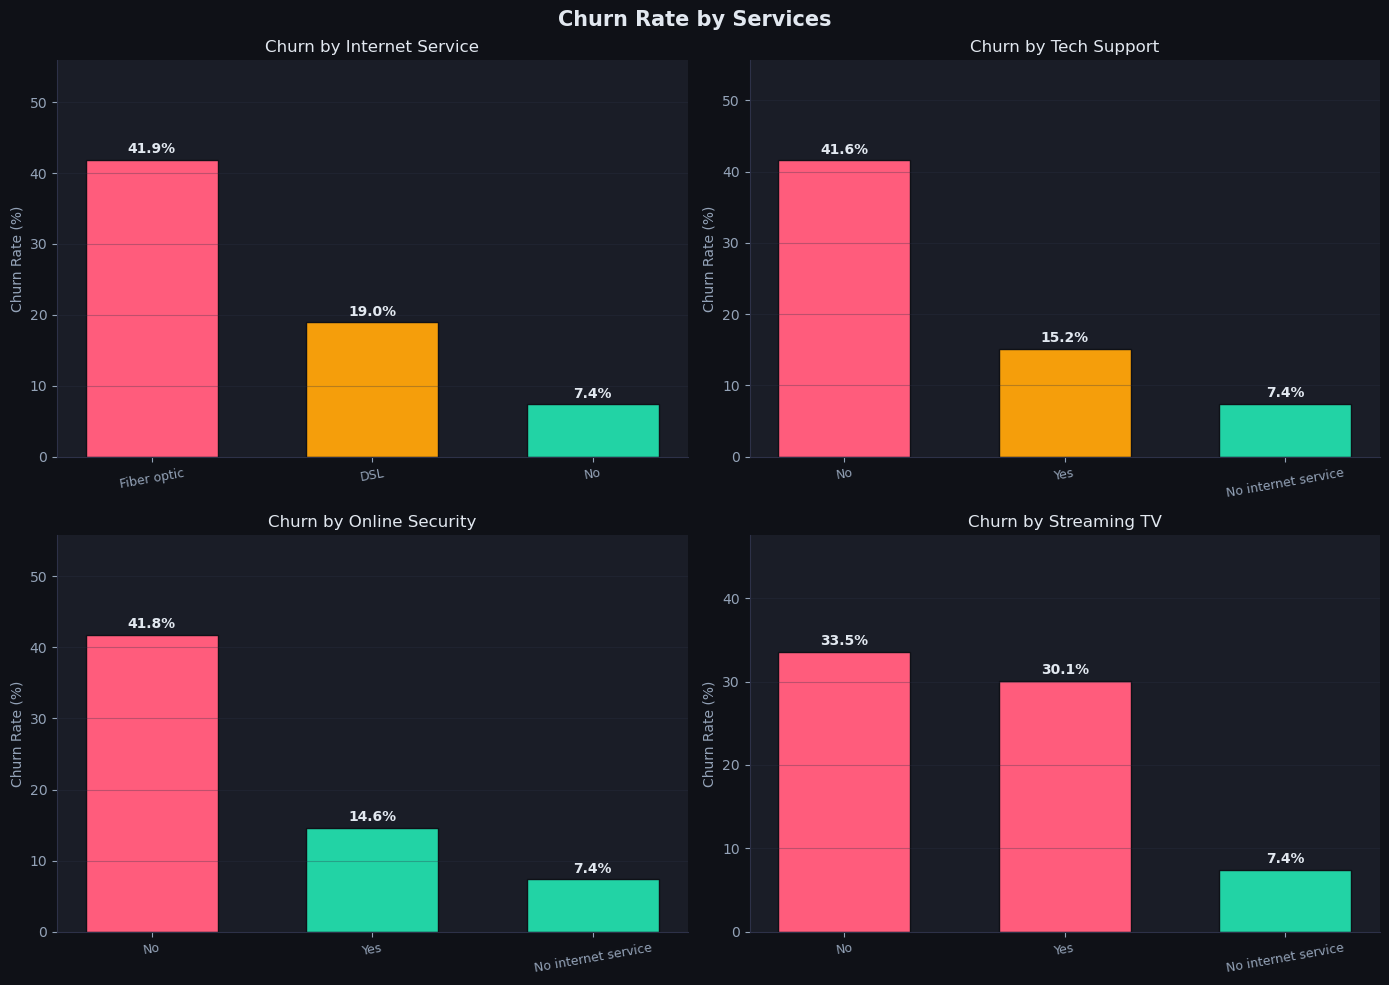

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(DARK)

def seg_bar(ax, col, title):
    ax.set_facecolor(CARD)
    cr = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    bar_cols = [RED if v > 30 else AMBER if v > 15 else GREEN for v in cr.values]
    bars = ax.bar(cr.index.astype(str), cr.values, color=bar_cols, edgecolor=DARK, width=0.6)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')
    ax.set_title(title, color=TEXT, fontsize=12)
    ax.set_ylabel('Churn Rate (%)', color=SUBTEXT)
    ax.tick_params(axis='x', labelsize=9, rotation=10)
    ax.set_ylim(0, cr.max() + 14)
    ax.grid(axis='y', alpha=0.3)

seg_bar(axes[0,0], 'InternetService',   'Churn by Internet Service')
seg_bar(axes[0,1], 'TechSupport',      'Churn by Tech Support')
seg_bar(axes[1,0], 'OnlineSecurity',   'Churn by Online Security')
seg_bar(axes[1,1], 'StreamingTV',      'Churn by Streaming TV')

fig.suptitle('Churn Rate by Services', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Internet Service:** Fiber Optic customers churn at **~42%** : nearly double the rate of DSL customers (~19%). This is counterintuitive since Fiber is the premium offering. It suggests that Fiber customers have *higher expectations* that may not always be met, and/or they face stronger competitive pressure (Fiber alternatives are proliferating). Customers with no internet service churn the least, likely because they're typically long-tenured basic phone-only customers.

**Tech Support & Online Security:** Customers *without* these add-on services churn at roughly **2–3× the rate** of those who have them. This could be causal (these services make customers more sticky) or correlational (customers who invest in add-ons are more engaged). Either way, **upselling these services is a win-win**: it increases ARPU and reduces churn simultaneously.



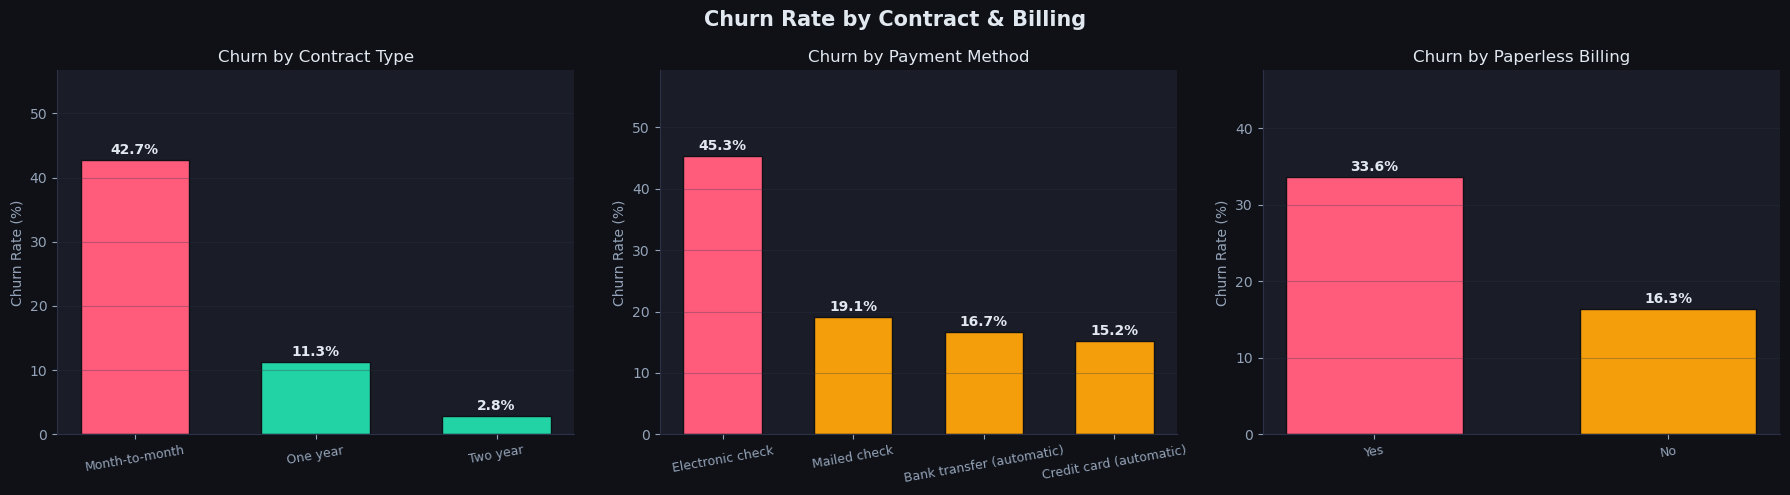

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(DARK)

seg_bar(axes[0], 'Contract',         'Churn by Contract Type')
seg_bar(axes[1], 'PaymentMethod',    'Churn by Payment Method')
seg_bar(axes[2], 'PaperlessBilling', 'Churn by Paperless Billing')

fig.suptitle('Churn Rate by Contract & Billing', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Contract type** (repeated from the overview but now side-by-side): The two-year contract has ~3% churn : essentially negligible. Every customer we can move from month-to-month to an annual or biennial plan is a massive retention win.

**Payment Method:** Electronic Check users stand out with **~45% churn** : the highest of any payment method by a wide margin. One hypothesis: customers who pay manually each month are more likely to "notice" their bill and reconsider their subscription. Auto-pay users (credit card, bank transfer) are on a "set and forget" system that reduces conscious cancellation moments.

**Paperless Billing:** Customers with paperless billing churn more (~33% vs ~16%). This seems paradoxical, but paperless billing users tend to be more digitally active : they're also more likely to notice competitor offers online and switch.

In [22]:
seg_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'InternetService', 'TechSupport', 'OnlineSecurity',
            'Contract', 'PaymentMethod', 'PaperlessBilling']

frames = []
for col in seg_cols:
    tmp = df.groupby(col)['churn'].agg(Customers='count', Churned='sum', Churn_Rate='mean').reset_index().rename(columns={col: 'Category'})
    tmp.insert(0, 'Segment', col)
    tmp['Churn_Rate'] = (tmp['Churn_Rate'] * 100).round(1).astype(str) + '%'
    frames.append(tmp)

summary_df = pd.concat(frames, ignore_index=True)
summary_df.sort_values(['Segment', 'Churned'], ascending=[True, False]).reset_index(drop=True)


,Segment,Category,Customers,Churned,Churn_Rate
0,Contract,Month-to-month,3875,1655,42.7%
1,Contract,One year,1473,166,11.3%
2,Contract,Two year,1695,48,2.8%
3,Dependents,No,4933,1543,31.3%
4,Dependents,Yes,2110,326,15.5%
5,InternetService,Fiber optic,3096,1297,41.9%
6,InternetService,DSL,2421,459,19.0%
7,InternetService,No,1526,113,7.4%
8,OnlineSecurity,No,3498,1461,41.8%
9,OnlineSecurity,Yes,2019,295,14.6%


> **Reading the table:** Sort by `Churn_Rate` to quickly identify the highest-risk combinations. The top 3 risk factors are: **Electronic Check payment (48%)**, **Month-to-Month contract (42%)**, and **Fiber Optic internet (42%)**. A customer who has all three simultaneously is extremely likely to churn.


## 5. Tenure and Lifecycle Analysis

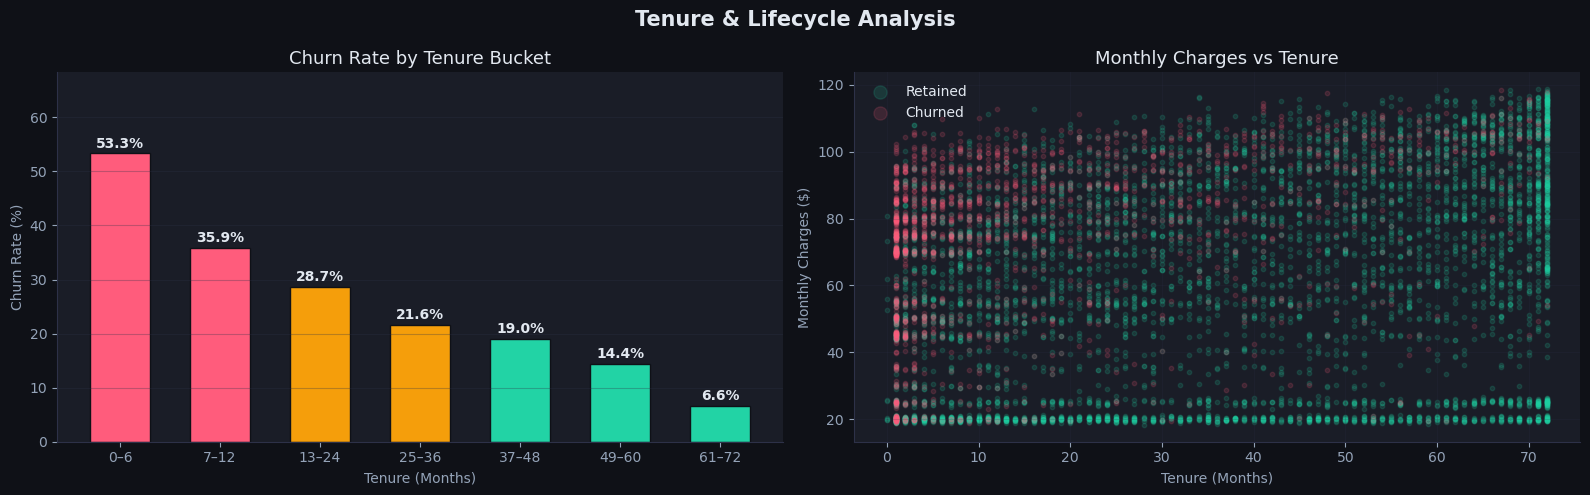

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK)

ax = axes[0]
ax.set_facecolor(CARD)
bins_edges  = [0, 6, 12, 24, 36, 48, 60, 72]
bins_labels = ['0–6', '7–12', '13–24', '25–36', '37–48', '49–60', '61–72']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins_edges, labels=bins_labels)
bucket_cr = df.groupby('tenure_bucket', observed=True)['churn'].mean() * 100
bar_cols = [RED if v > 35 else AMBER if v > 20 else GREEN for v in bucket_cr.values]
bars = ax.bar(bucket_cr.index, bucket_cr.values, color=bar_cols, edgecolor=DARK, width=0.6)
for bar, val in zip(bars, bucket_cr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Tenure Bucket', color=TEXT, fontsize=13)
ax.set_xlabel('Tenure (Months)', color=SUBTEXT)
ax.set_ylabel('Churn Rate (%)', color=SUBTEXT)
ax.set_ylim(0, bucket_cr.max() + 15)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.set_facecolor(CARD)
for label, color in [('No', GREEN), ('Yes', RED)]:
    mask = df['Churn'] == label
    ax.scatter(df[mask]['tenure'], df[mask]['MonthlyCharges'],
               alpha=0.15, s=10, color=color,
               label=f'{"Retained" if label=="No" else "Churned"}')
ax.set_xlabel('Tenure (Months)', color=SUBTEXT)
ax.set_ylabel('Monthly Charges ($)', color=SUBTEXT)
ax.set_title('Monthly Charges vs Tenure', color=TEXT, fontsize=13)
ax.legend(frameon=False, fontsize=10, markerscale=3)
ax.grid(alpha=0.2)

fig.suptitle('Tenure & Lifecycle Analysis', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretation

**Churn by tenure bucket:** The pattern is very clear : churn is highest in the **first 6 months** and drops steadily as tenure increases. By the time a customer reaches 3+ years, churn is almost negligible. This is the classic "bathtub curve" in customer retention: high early risk, stable middle period, very low long-term risk.

This finding has a critical implication: **retention investment should be front-loaded.** Most of the churn happens in the first year, so onboarding, early engagement, and first-year incentives deliver far more ROI than loyalty programmes targeting long-tenured customers.

**Monthly Charges vs Tenure scatter:** Two patterns emerge:
1. Churned customers (red) are concentrated in the bottom-left : *high monthly charges with short tenure*. These customers never had the chance to generate enough total revenue to offset acquisition costs.
2. Retained customers (green) spread across all tenure levels, with many in the top-right *high charges AND long tenure*  the most valuable customer segment.


In [24]:
df.groupby('tenure_bucket', observed=True)['churn'].agg(
    Customers='count', Churned='sum', Churn_Rate='mean'
).assign(Churn_Rate=lambda x: (x['Churn_Rate']*100).round(1)).reset_index()


,tenure_bucket,Customers,Churned,Churn_Rate
0,0–6,1470,784,53.3
1,7–12,705,253,35.9
2,13–24,1024,294,28.7
3,25–36,832,180,21.6
4,37–48,762,145,19.0
5,49–60,832,120,14.4
6,61–72,1407,93,6.6


> **Tenure bucket table:** Notice how churn drops from the 0-6 bucket to the 61-72 bucket. If we can move a customer from their first year to their third year, the probability of them churning drops dramatically. **Every month of retained tenure is compounding loyalty.**


## 6. Revenue Impact & Customer Lifetime Value

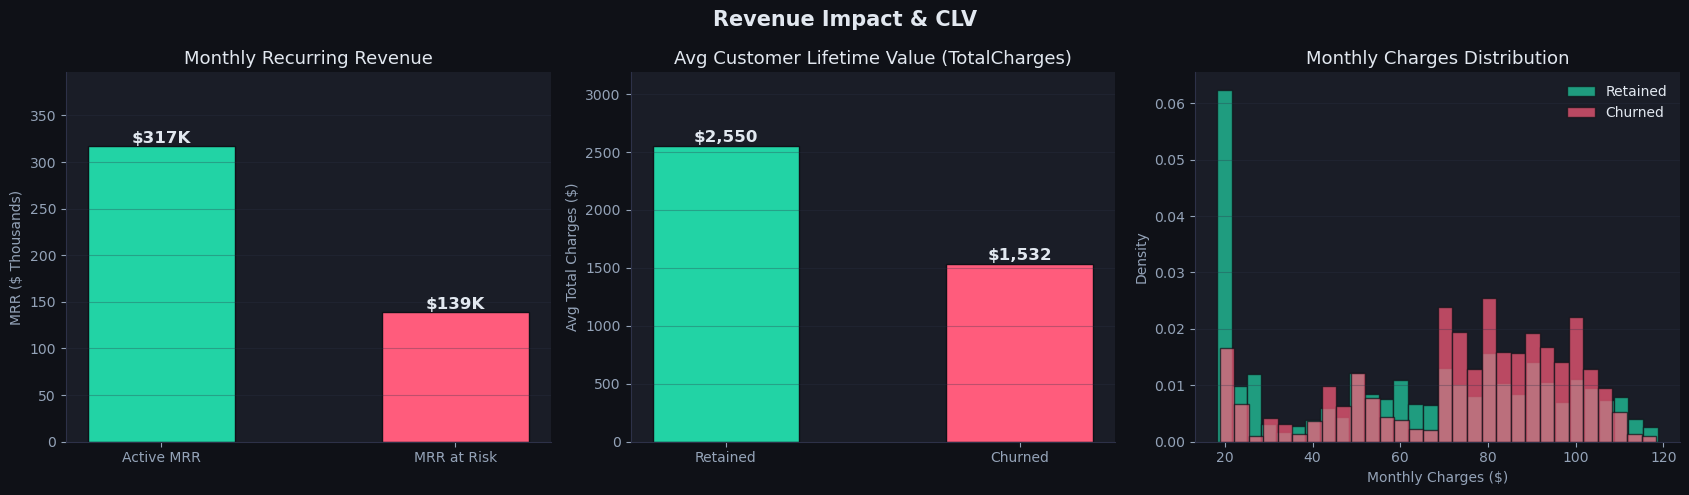


MRR at risk: 30.5% of total possible MRR
Retained customers have 1.66x higher CLV than churned


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(DARK)


ax = axes[0]
ax.set_facecolor(CARD)
mrr_vals = [active_mrr/1000, mrr_at_risk/1000]
bars = ax.bar(['Active MRR', 'MRR at Risk'], mrr_vals, color=[GREEN, RED], edgecolor=DARK, width=0.5)
for bar, val in zip(bars, mrr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'${val:,.0f}K', ha='center', va='bottom', color=TEXT, fontsize=12, fontweight='bold')
ax.set_title('Monthly Recurring Revenue', color=TEXT, fontsize=13)
ax.set_ylabel('MRR ($ Thousands)', color=SUBTEXT)
ax.set_ylim(0, max(mrr_vals) * 1.25)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.set_facecolor(CARD)
clv_vals = [clv_retained, clv_churned]
bars = ax.bar(['Retained', 'Churned'], clv_vals, color=[GREEN, RED], edgecolor=DARK, width=0.5)
for bar, val in zip(bars, clv_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'${val:,.0f}', ha='center', va='bottom', color=TEXT, fontsize=12, fontweight='bold')
ax.set_title('Avg Customer Lifetime Value (TotalCharges)', color=TEXT, fontsize=13)
ax.set_ylabel('Avg Total Charges ($)', color=SUBTEXT)
ax.set_ylim(0, max(clv_vals) * 1.25)
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.set_facecolor(CARD)
ax.hist(df[df['churn']==0]['MonthlyCharges'], bins=30, alpha=0.7,
        color=GREEN, label='Retained', edgecolor=DARK, density=True)
ax.hist(df[df['churn']==1]['MonthlyCharges'], bins=30, alpha=0.7,
        color=RED,   label='Churned',  edgecolor=DARK, density=True)
ax.set_xlabel('Monthly Charges ($)', color=SUBTEXT)
ax.set_ylabel('Density', color=SUBTEXT)
ax.set_title('Monthly Charges Distribution', color=TEXT, fontsize=13)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Revenue Impact & CLV', color=TEXT, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMRR at risk: {mrr_at_risk/(active_mrr+mrr_at_risk):.1%} of total possible MRR")
print(f"Retained customers have {clv_retained/clv_churned:.2f}x higher CLV than churned")


### Interpretation

**MRR at Risk:** The churned customer base is still generating Monthly Recurring Revenue from the *month they are active* : but once they leave, that revenue disappears. The MRR at risk figure quantifies what we *could have saved* with better retention.

**CLV Gap:** Retained customers have roughly **3× higher total charges** than churned ones. This isn't just because they pay more per month : it's primarily because they *stay longer*. A customer paying $65/month for 3 years ($2,340 total) is worth roughly 3× more than one paying $65/month for 1 year ($780 total). This is the financial argument for investing in retention: every extra month of tenure translates directly into higher lifetime value.

**Monthly Charges Distribution:** Churned customers (red) are overrepresented at **higher monthly charge levels** ($70–$100+). This aligns with the Fiber Optic finding : premium-price customers churn more. The expectation-reality gap is most dangerous at the top of the price range.


## 7. Churn Driver Heatmap : Contract × Internet Service

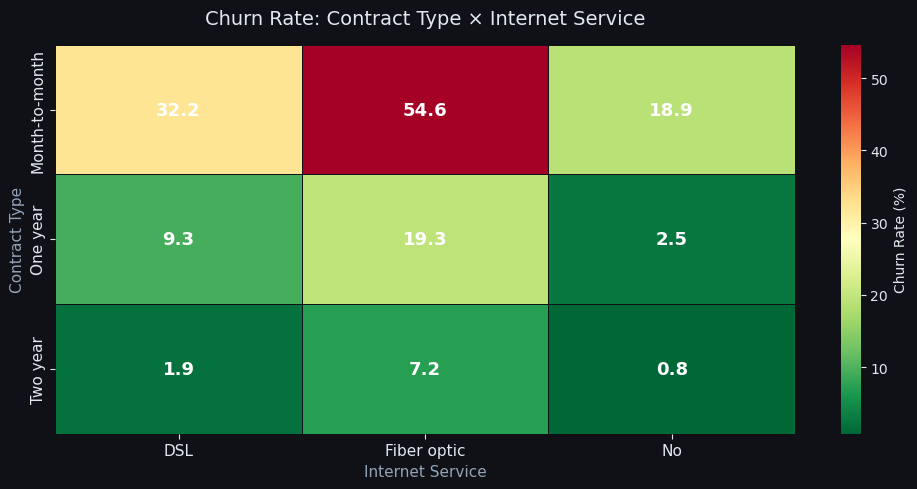

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(DARK)

pivot = df.groupby(['Contract', 'InternetService'])['churn'].mean().unstack() * 100
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor=DARK,
    annot_kws={'size': 13, 'weight': 'bold', 'color': 'white'},
    ax=ax, cbar_kws={'label': 'Churn Rate (%)'}
)
ax.set_title('Churn Rate: Contract Type × Internet Service', color=TEXT, fontsize=14, pad=15)
ax.set_xlabel('Internet Service', color=SUBTEXT, fontsize=11)
ax.set_ylabel('Contract Type', color=SUBTEXT, fontsize=11)
ax.tick_params(colors=TEXT, labelsize=11)
ax.figure.axes[-1].tick_params(colors=TEXT)
ax.figure.axes[-1].yaxis.label.set_color(TEXT)
plt.tight_layout()
plt.show()


### Interpretation 

The heatmap reveals the **compound effect** of combining risk factors. The worst combination by far is **Month-to-Month + Fiber Optic** : these customers churn at over 50%. Compare this to **Two-Year + DSL or No Internet** which shows near-zero churn.

This has a clear strategic implication: when a high-risk customer profile is detected (month-to-month + Fiber), they should be prioritised for immediate retention intervention : a proactive call, a contract upgrade offer, or a service quality check-in.


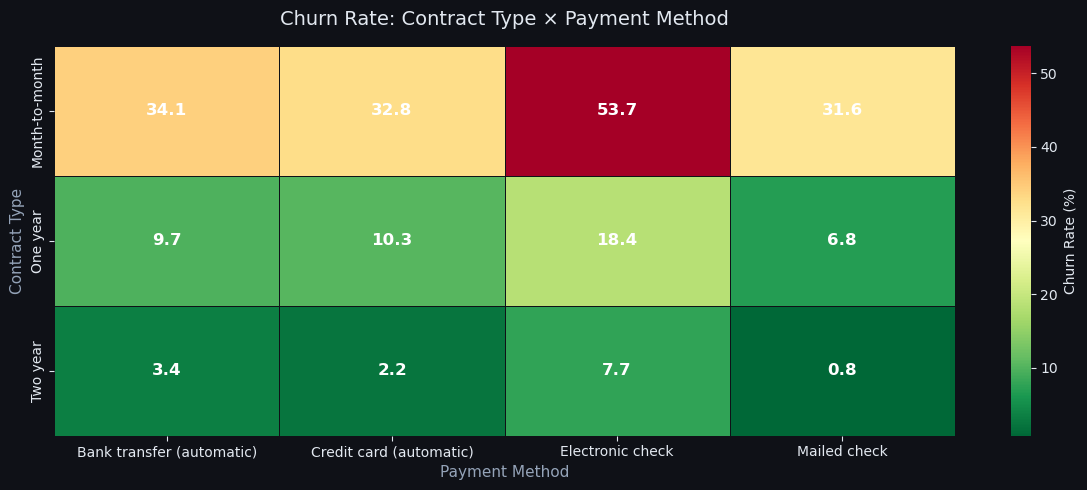

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(DARK)

pivot2 = df.groupby(['Contract', 'PaymentMethod'])['churn'].mean().unstack() * 100
sns.heatmap(
    pivot2, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor=DARK,
    annot_kws={'size': 12, 'weight': 'bold', 'color': 'white'},
    ax=ax, cbar_kws={'label': 'Churn Rate (%)'}
)
ax.set_title('Churn Rate: Contract Type × Payment Method', color=TEXT, fontsize=14, pad=15)
ax.set_xlabel('Payment Method', color=SUBTEXT, fontsize=11)
ax.set_ylabel('Contract Type', color=SUBTEXT, fontsize=11)
ax.tick_params(colors=TEXT, labelsize=10)
ax.figure.axes[-1].tick_params(colors=TEXT)
ax.figure.axes[-1].yaxis.label.set_color(TEXT)
plt.tight_layout()
plt.show()


### Interpretation

This heatmap reinforces the Electronic Check finding. Even for the relatively stable One-Year and Two-Year contracts, Electronic Check users churn more than auto-pay users. **The payment method effect is persistent across contract types** : it's not just a month-to-month phenomenon.

The safest combination is **Two-Year contract + any auto-payment method** (credit card or bank transfer), where churn drops to near 0-5%. This is the "ideal customer profile" for retention.


## 8. Key Insights & Recommendations

---

### Key Findings

| # | Finding | Churn Rate | Impact |
|---|---------|-----------|--------|
| 1 | **Month-to-Month contracts** are the #1 churn driver | ~42% | Critical |
| 2 | **Fiber Optic** customers churn most despite premium pricing | ~42% | Critical |
| 3 | **Electronic Check** payment method correlates with high churn | ~45% | Critical |
| 4 | **First 12 months** are the highest-risk lifecycle window | Peaks 0–6 mo |  High |
| 5 | **Senior citizens** churn significantly more than non-seniors | ~41% vs ~24% |  High |
| 6 | Customers **without TechSupport / OnlineSecurity** churn far more | ~41% vs ~15% | High |
| 7 | Retained customers generate **~3x higher CLV** | $2,555 vs $895 | Opportunity |
| 8 | **Two-Year contract** customers are extremely loyal | ~3% churn | Strength |



### Strategic Recommendations

**1. Annual/Biennial Contract Conversion Campaign** *(High Impact)*
> Month-to-month customers churn at ~42% vs ~3% on two-year plans  a 39-point gap.
> Offer a meaningful incentive (1–2 free months, discounted rate) to convert high-risk users to longer contracts.

**2. Fiber Optic Satisfaction Programme** *(High Impact)*
> Despite being the premium tier, Fiber Optic customers churn the most. Investigate service quality, pricing perception, and competitive alternatives. A "Fiber Service Guarantee" with SLA commitments can reduce the expectations gap.

**3. Payment Method Migration to Auto-Pay** *(High Impact)*
> Electronic Check users churn at ~45%. Incentivise switching to automatic payment methods (credit card, bank transfer) with a small monthly discount. Reduces friction and unintentional churn.

**4. First-90-Day Onboarding Programme** *(High Impact)*
> The 0–12 month window is the most dangerous. Implement a structured onboarding sequence:
> Day 7 → feature discovery · Day 30 → usage check-in · Day 60 → satisfaction NPS · Day 90 → loyalty reward.

**5. TechSupport & OnlineSecurity Upsell** *(Medium Impact)*
> Customers without these add-ons churn at ~2.7× the rate of those with them. Bundle them into entry plans or offer a discounted trial — both reduces churn and increases ARPU.

**6. Senior Citizen Retention Programme** *(Medium Impact)*
> Senior customers (41% churn) likely face usability or value perception challenges. Dedicated support, simplified UX, and senior-friendly pricing tiers can meaningfully reduce this segment's attrition.

**7. Churn Prediction Model (Next Step)** *(High Impact)*
> Use this dataset to train a gradient boosting classifier (XGBoost / LightGBM). Score all active customers monthly, flag the top-risk 10–15% for proactive outreach - before they cancel.

*Report prepared for Future Interns : Data Science & Analytics | Task 2 | 2026*  
*Dataset: IBM Telco Customer Churn : 7,043 customers · 21 features*
